# Random Forest for Breast Cancer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

cancer = datasets.load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
print('Loaded {} cancer training examples with {} features.'.format(cancer.data.shape[0],cancer.data.shape[1]))
print('Classification categories:', cancer.target_names)

# For Linear models we had 98% Accuracy
# For single decision Trees we got around 95% Accuracy 

Loaded 569 cancer training examples with 30 features.
Classification categories: ['malignant' 'benign']


**Fight DecisionTree Vs RandomForest**

In [2]:
from sklearn.ensemble import RandomForestClassifier
RandomForestClassifier?

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train,y_train)

print('Decision-Tree:')
print('  Accuarcy on training data: {:.3f}'.format(tree.score(X_train, y_train)))
print('  Accuarcy on test data    : {:.3f}'.format(tree.score(X_test, y_test)))

forest = RandomForestClassifier(n_estimators=100, random_state=3)
forest.fit(X_train,y_train)

print('Random Forest:')
print('   Accuarcy on training data: {:.3f}'.format(forest.score(X_train, y_train)))
print('   Accuarcy on test data    : {:.3f}'.format(forest.score(X_test, y_test)))

#dir(forest)
#forest.feature_importances_

Decision-Tree:
  Accuarcy on training data: 0.993
  Accuarcy on test data    : 0.923
Random Forest:
   Accuarcy on training data: 1.000
   Accuarcy on test data    : 0.972


**Getting knowledge about the created internal model**

Text(0.5, 1.0, 'Forest')

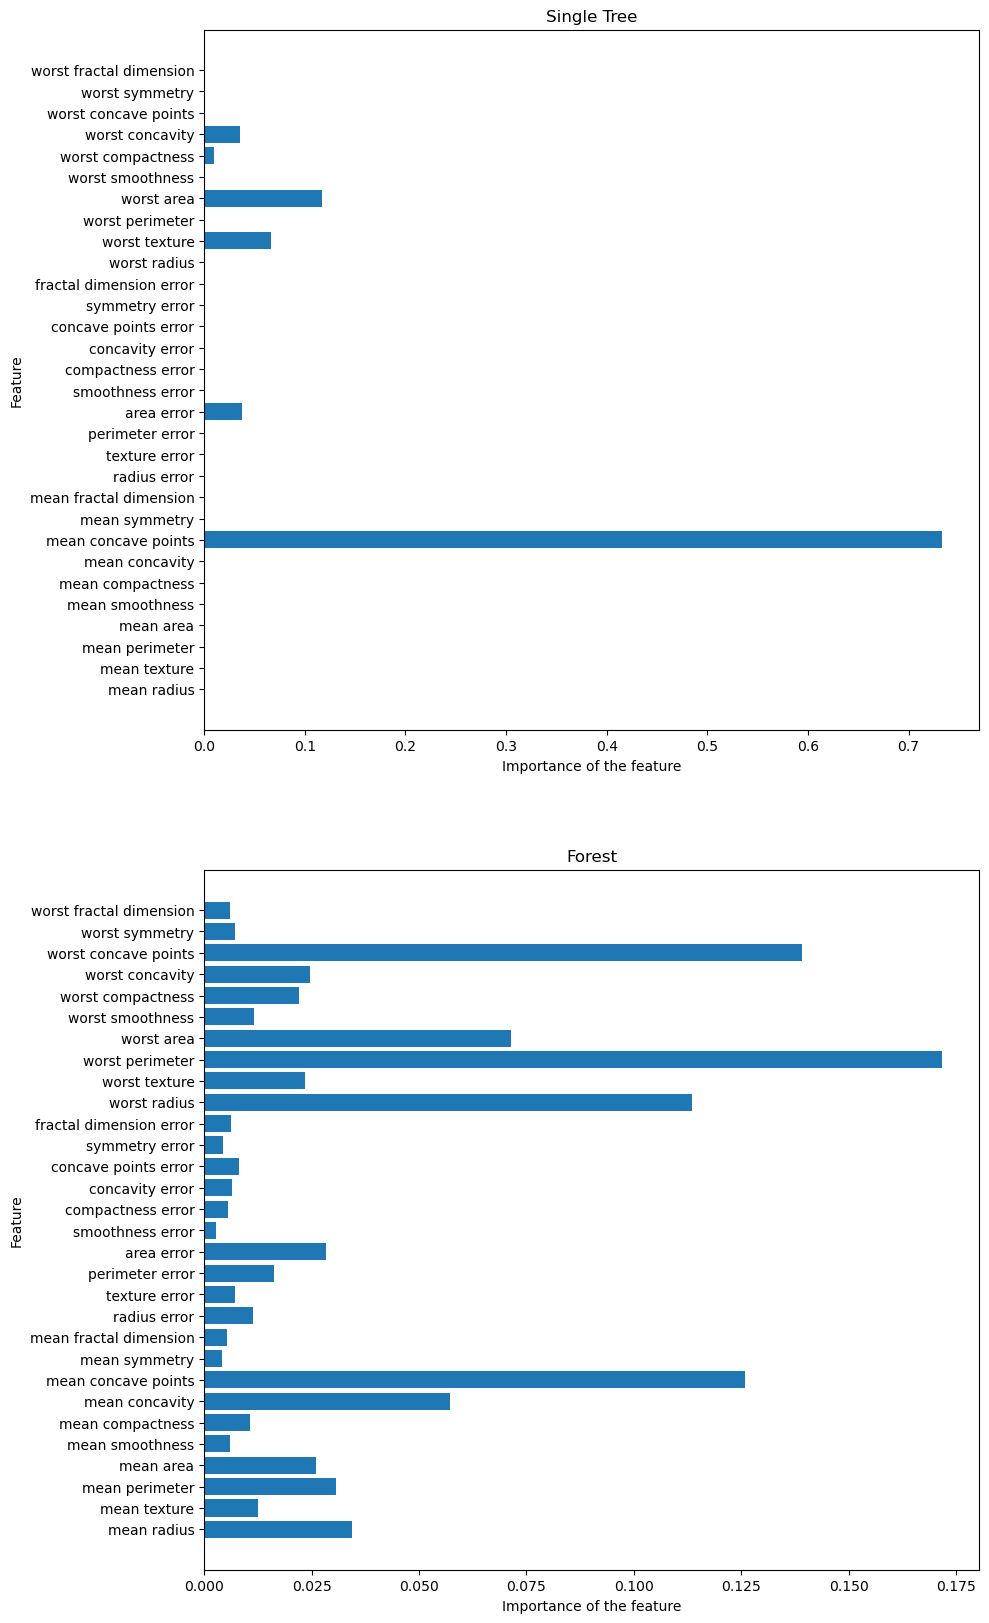

In [5]:
def plot_feature_importances_cancer(model, ax):
    n_features = cancer.data.shape[1]
    ax.barh(range(n_features),model.feature_importances_, align='center')
    ax.set_yticks(np.arange(n_features))
    ax.set_yticklabels(cancer.feature_names)
    ax.set_xlabel('Importance of the feature');
    ax.set_ylabel('Feature')
    
fig, axes = plt.subplots(2,1)
fig.set_size_inches(10, 20)
plot_feature_importances_cancer(tree, axes[0])
plot_feature_importances_cancer(forest, axes[1])
axes[0].set_title("Single Tree")
axes[1].set_title("Forest")


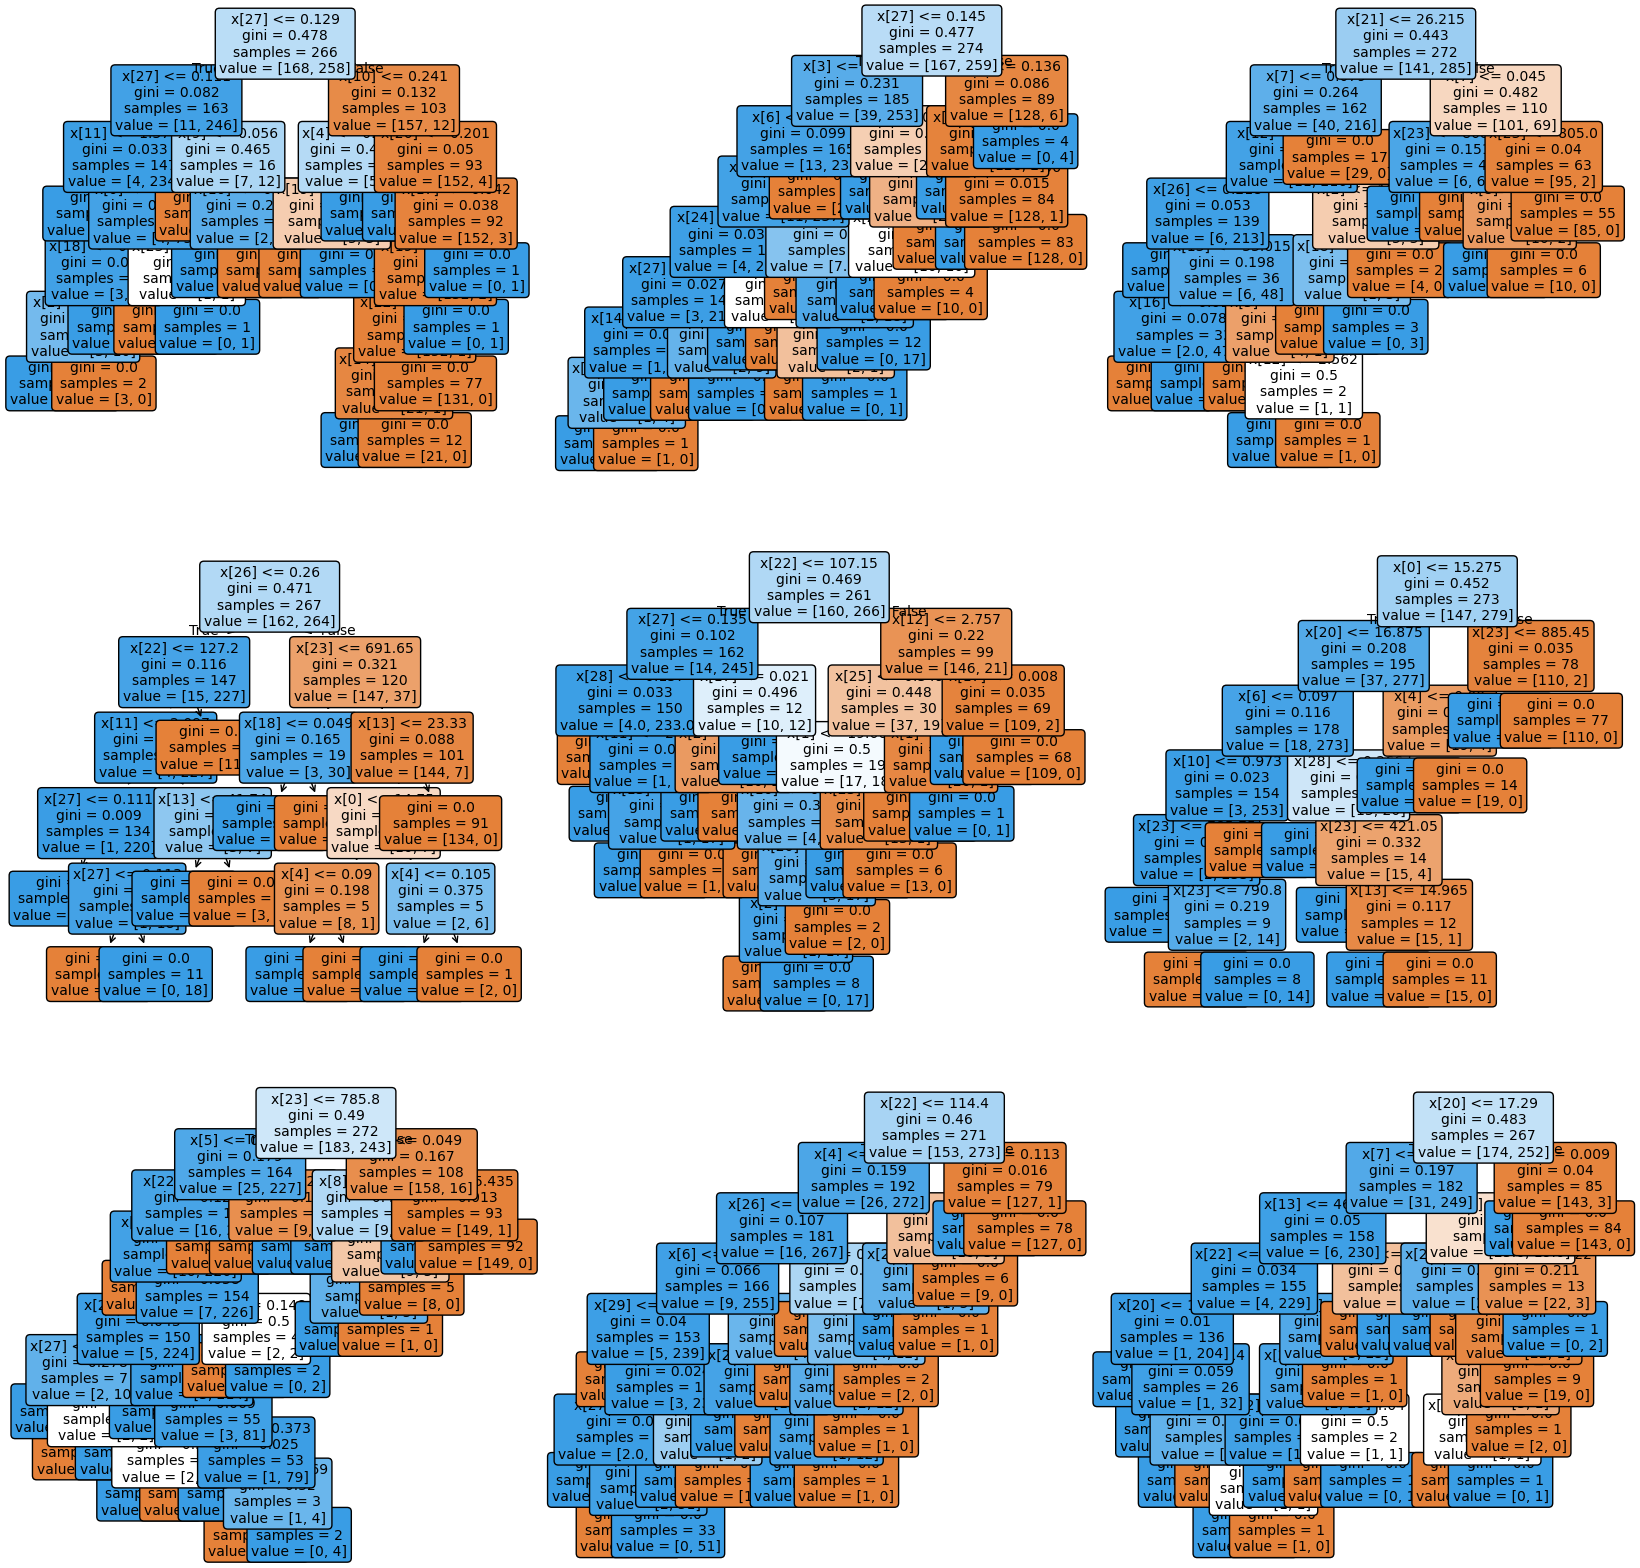

In [6]:
from sklearn import tree
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3,3,figsize=(20,20))
for i, (ax, clf) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Baum {}".format(i))
    tree.plot_tree(clf, fontsize=10, rounded=True, filled=True, ax=ax)
    if i==8: 
        break 
        
    

In [ ]:
from sklearn import tree

for i, clf in enumerate(forest.estimators_):
    print('----Tree', i)
    print('Accuracy on Training Data: {:.3f}'.format(clf.score(X_train,y_train)))
    print('Accuracy on Test Data: {:.3f}'.format(clf.score(X_test,y_test)))
    print('Depth of the Tree',clf.get_depth())
    print('Leaves of the Tree', clf.get_n_leaves())
    if i==3: 
        break 
    